# Simulation of an Metal Oxide Semiconductor Diode


The following code loads the needed modules.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import  ohm_potential, calc_p_density, calc_n_density, calc_recombination


import synumses.one_dimension.solver as solver


## Definition of the geometry of the MOS Diode
The band gap of $\mathrm{SiO_x}$ is set to $E_\mathrm{g} = 5.3\,\mathrm{eV}$.<br>
The doping level of the silicon is set to $N_\mathrm{a}=1\¢dot 10^{14}\,\mathrm{cm^3}$.

In [2]:
parameters.n = 600 #610
parameters.lx = 2400E-9 #2440E-9

parameters.init_geometry()

#parameters.Cau = 0*1E-24  

Nd_SiO   = 0.0
Na_Si    = 1.0E20

Er_SiO = 4.0
Er_Si = 11.6

Ec_Si  = 1.12
Ev_Si  = 0.0

Ec_SiO = 2.9
Ev_SiO = -2.4

# Transition SiO to Si
x1 = 10E-9

for i in range(0, parameters.n):
    
    if parameters.pos_x[i] < x1:
        parameters.Ec[i] = Ec_SiO
        parameters.Ev[i] = Ev_SiO
        
        parameters.Epsilon[i] =  parameters.Epsilon_0 * Er_SiO      
        
        parameters.C[i] = + Nd_SiO
        
    else:
        parameters.Ec[i] = Ec_Si
        parameters.Ev[i] = Ev_Si
        
        parameters.Epsilon[i] =  parameters.Epsilon_0 * Er_Si
        
        parameters.C[i] = - Na_Si
   

## Plot MOS structure

Now, we plot the default band diagramm and the doping levels

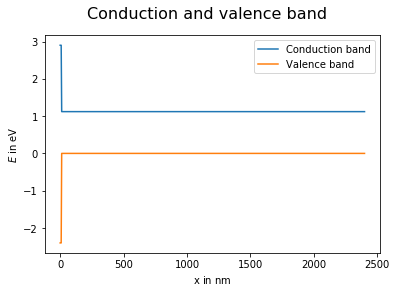

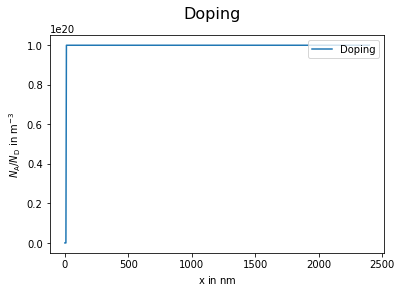

In [3]:
# Band diagramm
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.Ec, label='Conduction band')
axis.plot(parameters.pos_x * 1E9, parameters.Ev, label='Valence band')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$E$ in $\mathrm{eV}$")

axis.legend()
plt.show()

# Doping level
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Doping", fontsize=16)

#axis.semilogy(np.abs(parameters.C), label='Doping')
axis.plot(parameters.pos_x * 1E9, np.abs(parameters.C), label='Doping')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$N_\mathrm{A} / N_\mathrm{D}$ in $\mathrm{m^{-3}}$")

axis.legend(loc='upper right')
plt.show()


## Simulaiton without biasing

For convergence the parameter *parameters.bernoulli_limit* was set to 2! 

Further the norm for $\Delta x$ is increased to *norm_max=1E-2*.


In [4]:
parameters.init_potential()

parameters.bernoulli_limit = 2.0

solver.solve_no_bias()

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


True

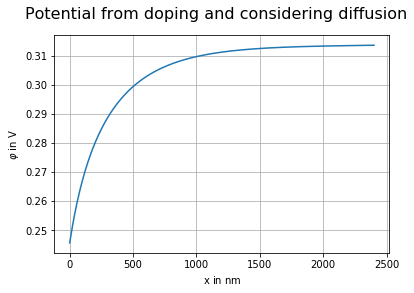

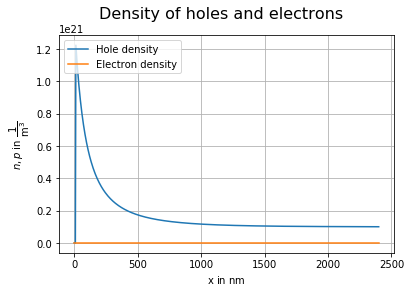

In [5]:
#solver.solve_no_bias()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from doping and considering diffusion", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3])

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

axis.grid()
plt.show()

# Hole and electron density
calc_p_density()
calc_n_density()

p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, p, label='Hole density')
axis.plot(parameters.pos_x * 1E9, n, label='Electron density')

#plt.ylim((0,.4E20))

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$n, p$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.grid()
axis.legend(loc='upper left')
plt.show() 

## Perform gate voltage sweep

Here the *norm_max=1E-2* is increased. 

The seewp is performed between $U_{Start}=0$ and $U_{Stop}=1.4$.

In [6]:
voltage = []
charge = []

parameters.Cau = np.full(parameters.n, 0) #1E-24

solver.solve_no_bias()

u_actual = 0.0
u_stop    = 1.4
u_step    = 0.05
voltage = []
current_density = []

while (u_actual<=u_stop):

    
    old_u = parameters.u.copy()
    step_back = 0.0
    while (True):
        print("Voltage:", u_actual + u_step/2**step_back)
        if (solver.solve_bias(u_actual + u_step/2**step_back,0, norm_max=1E-2) == True):
            
            u_actual = u_actual + u_step/2**step_back
            break
            
        parameters.u = old_u.copy()
        step_back    = step_back + 1.0
        
        
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(u_actual)
    calc_n_density()
    charge.append(parameters.n_density.sum())
  

Voltage: 0.05
Norm of b:  0.05000000000138253
Norm of x: 0.2572120990446752
Norm of b:  7.614040611316203e-05
Norm of x: 0.04908719146611111
Norm of b:  7.108454906152859e-07
Norm of x: 0.003115795201920453
Voltage: 0.1
Norm of b:  0.05000000000179076
Norm of x: 0.3360597549362035
Norm of b:  2.2503061621446208e-05
Norm of x: 0.04600679205041635
Norm of b:  3.436689418383623e-07
Norm of x: 0.001095605849905364
Voltage: 0.15000000000000002
Norm of b:  0.05000000000090487
Norm of x: 0.4097925334308926
Norm of b:  7.253016630876472e-06
Norm of x: 0.040537847756493425
Norm of b:  2.5628258024399563e-07
Norm of x: 0.0006801058420505054
Voltage: 0.2
Norm of b:  0.05000000000076842
Norm of x: 0.4713901367628679
Norm of b:  3.1551308803483066e-06
Norm of x: 0.034399566507811674
Norm of b:  2.2189329389435357e-07
Norm of x: 0.0004389646635242775
Voltage: 0.25
Norm of b:  0.05000000000056365
Norm of x: 0.5211624482227962
Norm of b:  1.8669054496550561e-06
Norm of x: 0.029077583065404044
Norm of 

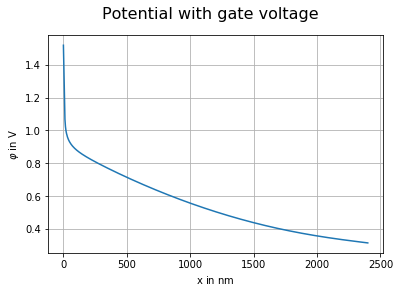

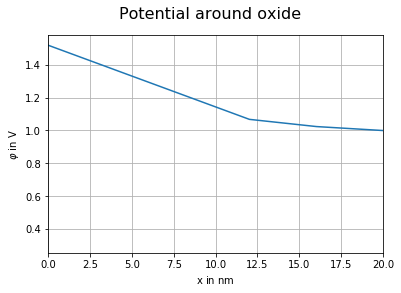

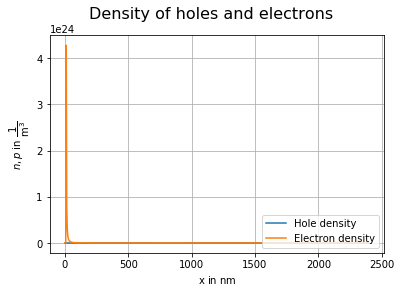

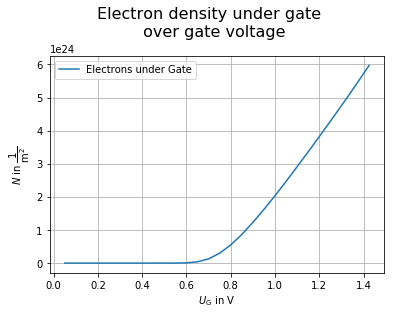

In [8]:
#
# Plot potential
#

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential with gate voltage", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3])

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

axis.grid()
plt.show()

#
# Plot potential at the oxide
#

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential around oxide", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3])

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

plt.xlim(0,20)

axis.grid()
plt.show()

#
# Hole and electron density
#
calc_p_density()
calc_n_density()

p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, p, label='Hole density')
axis.plot(parameters.pos_x * 1E9, n, label='Electron density')

#plt.ylim((0,.4E20))

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$n, p$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.grid()
axis.legend(loc='lower right')
plt.show() 


#
# Electron density under gate
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Electron density under gate \n over gate voltage", y=1.05,fontsize=16)

axis.plot(voltage, charge ,label='Electrons under Gate')

axis.set_xlabel(r"$U_\mathrm{G}$ in $\mathrm{V}$")
axis.set_ylabel(r"$N$ in $\mathrm{\dfrac{1}{m^2}}$")

axis.grid()
axis.legend(loc='upper left')
plt.savefig("Charge.png")
plt.show() 